# West Coast Housing Analysis: Part 1: Data Structuring & Cleaning

**Source:** Zillow Research Data: Zillow Home Value Index (ZHVI), All Homes, Mid-Tier  
**URL:** https://www.zillow.com/research/data/  
**Geography:** West Coast cities (California, Washington, Oregon, and Nevada)

**Time Coverage:** June 2015 – June 2025 (121 months)  

---

## What is ZHVI?

The **Zillow Home Value Index (ZHVI)** measures the typical home value and market changes across a given region. The mid-tier cut used here reflects homes in the **35th–65th percentile** of value for each city. Starting with the January 2023 release, Zillow upgraded the full time series to use the neural Zestimate model, improving accuracy significantly.

This notebook handles three tasks:
1. **Profiling**: understand shape, dtypes, and coverage
2. **Reshaping**: pivot from wide (one column per month) to long (one row per city-month)
3. **Cleaning**: handle missing values, engineer derived columns, and export analysis-ready files

## 1) Imports & Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Consistent aesthetics across all notebooks

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

# Display settings

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Libraries loaded.')

Libraries loaded.


## 2) Load Raw Data

In [2]:
df_raw = pd.read_csv('Zillow_Project_prices_West_Coast_(Raw).csv')

print(f'Raw shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.2f} MB')

Raw shape: 1,406 rows × 128 columns
Memory usage: 1.80 MB


## 3) Structural Profile

The raw file is in **wide format**: 7 metadata columns followed by 121 date columns (one per month). Each row is a city; each date column holds that city's ZHVI for that month.

In [7]:
# Separate metadata from time series columns

META_COLS = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'State', 'Metro', 'CountyName']
DATE_COLS = [c for c in df_raw.columns if c not in META_COLS]

print(f'Metadata columns: {len(META_COLS)}')
print(f'Time series columns: {len(DATE_COLS)}')
print(f'  First period: {DATE_COLS[0]}')
print(f'  Last period:  {DATE_COLS[-1]}')
print()
print('Column dtypes (metadata):')
print(df_raw[META_COLS].dtypes)

Metadata columns: 7
Time series columns: 121
  First period: 6/30/15
  Last period:  6/30/25

Column dtypes (metadata):
RegionID       int64
SizeRank       int64
RegionName    object
RegionType    object
State         object
Metro         object
CountyName    object
dtype: object


In [8]:
# Geographic coverage

print('=== Geographic Coverage ===')
print(f'Total cities: {len(df_raw):,}')
print(f'States:       {df_raw["State"].nunique()}')
print(f'Metro areas:  {df_raw["Metro"].nunique()}')
print(f'Counties:     {df_raw["CountyName"].nunique()}')
print()
print('Cities per state:')
print(df_raw['State'].value_counts().to_frame('city_count'))

=== Geographic Coverage ===
Total cities: 1,406
States:       4
Metro areas:  84
Counties:     114

Cities per state:
       city_count
State            
CA            819
WA            314
OR            234
NV             39


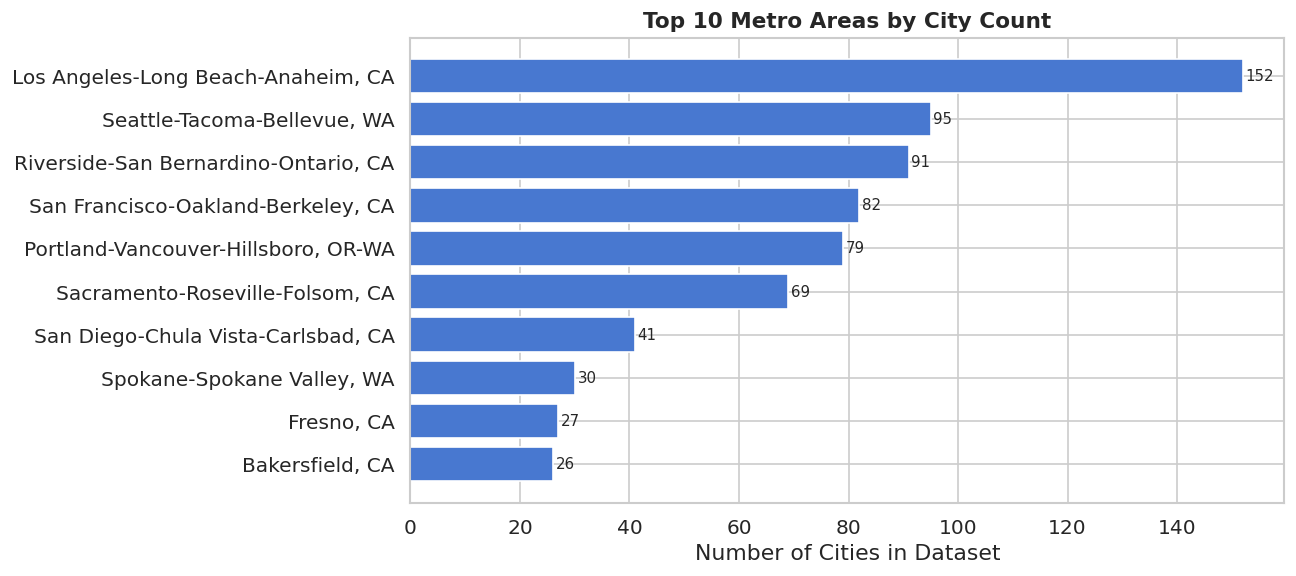

In [10]:
import os

# Top metros by city count

metro_counts = df_raw['Metro'].value_counts().head(10).reset_index()
metro_counts.columns = ['Metro', 'City Count']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(metro_counts['Metro'][::-1], metro_counts['City Count'][::-1],
               color=sns.color_palette('muted')[0], edgecolor='white')
ax.set_xlabel('Number of Cities in Dataset')
ax.set_title('Top 10 Metro Areas by City Count', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9)
plt.tight_layout()

# Create the 'outputs' directory if it doesn't exist

os.makedirs('outputs', exist_ok=True)

plt.savefig('outputs/metro_city_counts.png', bbox_inches='tight')
plt.show()

## 4) Missing Value Analysis

In [13]:
# Metadata nulls

meta_nulls = df_raw[META_COLS].isnull().sum()
print('Nulls in metadata columns:')
print(meta_nulls[meta_nulls > 0] if meta_nulls.any() else '  None — metadata is complete.')
print()

# Time series nulls

ts_nulls = df_raw[DATE_COLS].isnull().sum()
ts_null_cols = ts_nulls[ts_nulls > 0]
print(f'Date columns with missing ZHVI values: {len(ts_null_cols)} of {len(DATE_COLS)}')
print()
if len(ts_null_cols) > 0:
    print('Affected months and null counts:')
    print(ts_null_cols.to_frame('null_count'))

print()
rows_with_any_null = df_raw[df_raw[DATE_COLS].isnull().any(axis=1)]
print(f'Cities with at least one missing ZHVI: {len(rows_with_any_null)}')
print('State breakdown of affected cities:')
print(rows_with_any_null['State'].value_counts())

Nulls in metadata columns:
  None — metadata is complete.

Date columns with missing ZHVI values: 9 of 121

Affected months and null counts:
          null_count
2/28/19            2
3/31/19            1
9/30/20           12
10/31/20          12
11/30/20           8
12/31/20           1
5/31/21            1
6/30/21            1
7/31/21            1

Cities with at least one missing ZHVI: 25
State breakdown of affected cities:
State
CA    22
OR     1
NV     1
WA     1
Name: count, dtype: int64


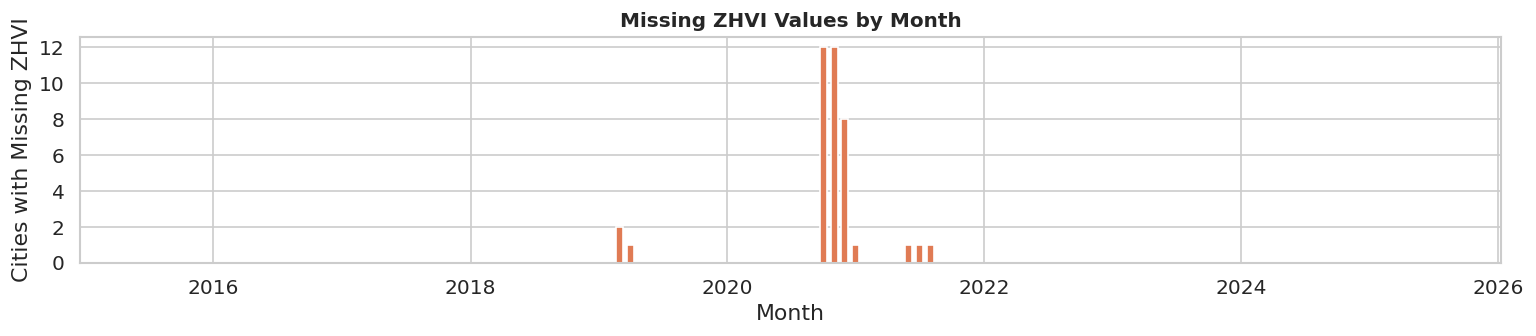


Observation: Nulls are concentrated in 2019–2021, consistent with data collection
gaps during and just before the COVID-19 period. The pattern is sparse and localized.


In [14]:
# Visualize null pattern in time series

null_by_month = df_raw[DATE_COLS].isnull().sum()
null_by_month.index = pd.to_datetime(null_by_month.index)

fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(null_by_month.index, null_by_month.values,
       color='#e07b54', width=20, edgecolor='white')
ax.set_title('Missing ZHVI Values by Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Cities with Missing ZHVI')
ax.set_xlabel('Month')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('outputs/missing_by_month.png', bbox_inches='tight')
plt.show()

print()
print('Observation: Nulls are concentrated in 2019–2021, consistent with data collection')
print('gaps during and just before the COVID-19 period. The pattern is sparse and localized.')

## 5) Reshape: Wide → Long Format

The wide format is useful for viewing all time periods at once, but **long format is required** for time series analysis, plotting, and SQL-style queries. We melt the 121 date columns into `(date, zhvi)` row pairs.

In [17]:
df_long = df_raw.melt(
    id_vars=META_COLS,
    value_vars=DATE_COLS,
    var_name='date_str',
    value_name='zhvi'
)

# Parse date

df_long['date'] = pd.to_datetime(df_long['date_str'], format='%m/%d/%y')
df_long = df_long.drop(columns='date_str')

# Sort

df_long = df_long.sort_values(['State', 'RegionName', 'date']).reset_index(drop=True)

print(f'Long format shape: {df_long.shape[0]:,} rows × {df_long.shape[1]} columns')
print(f'  = {len(df_raw):,} cities × {len(DATE_COLS)} months')
print()
print('Sample rows:')
df_long.head(5)

Long format shape: 170,126 rows × 9 columns
  = 1,406 cities × 121 months

Sample rows:


,RegionID,SizeRank,RegionName,RegionType,State,Metro,CountyName,zhvi,date
0,43820,6845,Acampo,city,CA,"Stockton, CA",San Joaquin County,"711,699.35",2015-06-30
1,43820,6845,Acampo,city,CA,"Stockton, CA",San Joaquin County,"709,120.80",2015-07-31
2,43820,6845,Acampo,city,CA,"Stockton, CA",San Joaquin County,"705,468.17",2015-08-31
3,43820,6845,Acampo,city,CA,"Stockton, CA",San Joaquin County,"705,895.16",2015-09-30
4,43820,6845,Acampo,city,CA,"Stockton, CA",San Joaquin County,"714,181.03",2015-10-31


## 6) Impute Missing ZHVI Values

**Strategy: forward-fill then backward-fill within each city.**

Missing values are sparse (≤12 cities per month) and clustered in 2019–2021. For a smoothed, seasonally adjusted index like ZHVI, linear interpolation is the most defensible approach, it avoids injecting artificial shocks into the series while being honest about the gap.

In [18]:
null_before = df_long['zhvi'].isnull().sum()

# Interpolate within each city's time series

df_long['zhvi'] = (
    df_long
    .groupby('RegionID')['zhvi']
    .transform(lambda s: s.interpolate(method='linear').ffill().bfill())
)

null_after = df_long['zhvi'].isnull().sum()

print(f'Null ZHVI values before imputation: {null_before:,}')
print(f'Null ZHVI values after imputation:  {null_after:,}')
print()
print('Imputation method: linear interpolation within each city, \n'
      'with forward-fill and backward-fill as fallback for edge gaps.')

Null ZHVI values before imputation: 39
Null ZHVI values after imputation:  0

Imputation method: linear interpolation within each city, 
with forward-fill and backward-fill as fallback for edge gaps.


## 7) Derived Feature Engineering

Engineering time-aware and cross-sectional features that will serve both the EDA (Part 2) and the predictive model (Part 3).

In [20]:
# Time features

df_long['year']    = df_long['date'].dt.year
df_long['month']   = df_long['date'].dt.month
df_long['quarter'] = df_long['date'].dt.quarter

# Lagged ZHVI (for Part 3 model features)

df_long = df_long.sort_values(['RegionID', 'date'])

df_long['zhvi_lag_1m']  = df_long.groupby('RegionID')['zhvi'].shift(1)   # 1-month lag
df_long['zhvi_lag_3m']  = df_long.groupby('RegionID')['zhvi'].shift(3)   # 3-month lag
df_long['zhvi_lag_12m'] = df_long.groupby('RegionID')['zhvi'].shift(12)  # 12-month lag

# Month-over-month % change

df_long['mom_pct_change'] = df_long.groupby('RegionID')['zhvi'].pct_change() * 100

# Year-over-year % change

df_long['yoy_pct_change'] = (
    df_long.groupby('RegionID')['zhvi']
    .pct_change(periods=12) * 100
)

# Rolling 3-month average (smoothing)

df_long['zhvi_rolling_3m'] = (
    df_long.groupby('RegionID')['zhvi']
    .transform(lambda s: s.rolling(3, min_periods=1).mean())
)

print('Engineered features added:')
new_cols = ['year','month','quarter','zhvi_lag_1m','zhvi_lag_3m','zhvi_lag_12m',
            'mom_pct_change','yoy_pct_change','zhvi_rolling_3m']
for c in new_cols:
    print(f'  • {c}')

Engineered features added:
  • year
  • month
  • quarter
  • zhvi_lag_1m
  • zhvi_lag_3m
  • zhvi_lag_12m
  • mom_pct_change
  • yoy_pct_change
  • zhvi_rolling_3m


In [21]:
# Verify: spot-check one city

sample = df_long[df_long['RegionName'] == 'Seattle'].tail(6)[[
    'RegionName', 'date', 'zhvi', 'mom_pct_change', 'yoy_pct_change', 'zhvi_lag_12m'
]]
print('Spot-check: Seattle — last 6 months')
sample

Spot-check: Seattle — last 6 months


,RegionName,date,zhvi,mom_pct_change,yoy_pct_change,zhvi_lag_12m
161408,Seattle,2025-01-31,"1,404,264.79",0.32,4.57,"1,342,911.79"
161409,Seattle,2025-02-28,"1,408,710.13",0.32,4.76,"1,344,701.69"
161410,Seattle,2025-03-31,"1,408,858.73",0.01,4.11,"1,353,272.34"
161411,Seattle,2025-04-30,"1,404,121.89",-0.34,2.78,"1,366,189.93"
161412,Seattle,2025-05-31,"1,394,031.98",-0.72,1.26,"1,376,721.12"
161413,Seattle,2025-06-30,"1,382,470.89",-0.83,0.20,"1,379,672.03"


## 8) Cross-Sectional Snapshot Table

Build a **city-level summary table** (one row per city) capturing key ZHVI statistics across the full 10-year window. This will be the primary input for the EDA and model.

In [22]:
# Snapshot dates

start_date = pd.Timestamp('2015-06-30')
end_date   = df_long['date'].max()

zhvi_start = df_long[df_long['date'] == start_date].set_index('RegionID')['zhvi']
zhvi_end   = df_long[df_long['date'] == end_date].set_index('RegionID')['zhvi']

city_stats = df_long.groupby(
    ['RegionID', 'RegionName', 'State', 'Metro', 'CountyName', 'SizeRank']
).agg(
    zhvi_min     = ('zhvi', 'min'),
    zhvi_max     = ('zhvi', 'max'),
    zhvi_mean    = ('zhvi', 'mean'),
    zhvi_std     = ('zhvi', 'std'),
    zhvi_median  = ('zhvi', 'median'),
    zhvi_current = ('zhvi', 'last'),
    avg_mom_change = ('mom_pct_change', 'mean'),
    avg_yoy_change = ('yoy_pct_change', 'mean'),
    months_positive_mom = ('mom_pct_change', lambda x: (x > 0).sum()),
).reset_index()

# 10-year appreciation

city_stats['zhvi_2015'] = city_stats['RegionID'].map(zhvi_start)
city_stats['pct_change_10yr'] = (
    (city_stats['zhvi_current'] - city_stats['zhvi_2015']) / city_stats['zhvi_2015'] * 100
)

# Volatility coefficient (std / mean)

city_stats['volatility_cv'] = city_stats['zhvi_std'] / city_stats['zhvi_mean']

print(f'City snapshot table: {city_stats.shape[0]:,} cities × {city_stats.shape[1]} features')
print()
print('Sample — top 5 by 10-year appreciation:')
city_stats.nlargest(5, 'pct_change_10yr')[[
    'RegionName','State','zhvi_2015','zhvi_current','pct_change_10yr'
]]

City snapshot table: 1,406 cities × 18 features

Sample — top 5 by 10-year appreciation:


,RegionName,State,zhvi_2015,zhvi_current,pct_change_10yr
959,Vader,WA,"179,528.31","491,212.05",173.61
575,Packwood,WA,"250,884.97","657,064.41",161.90
1198,Bucoda,WA,"161,203.63","417,995.11",159.30
991,Winlock,WA,"253,119.76","643,992.73",154.42
548,Landers,CA,"151,344.08","379,132.53",150.51


## 9) Data Quality Summary

In [25]:

print('Data Quality: Summary\n')

print(f'Total city-month observations:  {len(df_long):,}')
print(f'Cities:                         {df_long["RegionID"].nunique():,}')
print(f'Months covered:                 {df_long["date"].nunique()}')
print(f'Date range:                     {df_long["date"].min().date()} → {df_long["date"].max().date()}')
print(f'Remaining null ZHVI:            {df_long["zhvi"].isnull().sum()}')
print()
print('ZHVI range (Jun 2025):')
latest = df_long[df_long['date'] == end_date]
print(f'  Min:    ${latest["zhvi"].min():>14,.0f}  ({latest.loc[latest["zhvi"].idxmin(), "RegionName"]})')
print(f'  Median: ${latest["zhvi"].median():>14,.0f}')
print(f'  Max:    ${latest["zhvi"].max():>14,.0f}  ({latest.loc[latest["zhvi"].idxmax(), "RegionName"]})')
print()
print('10-Year Appreciation (Jun 2015 → Jun 2025):')
print(f'  Mean:   {city_stats["pct_change_10yr"].mean():.1f}%')
print(f'  Median: {city_stats["pct_change_10yr"].median():.1f}%')
print(f'  Max:    {city_stats["pct_change_10yr"].max():.1f}%  ({city_stats.loc[city_stats["pct_change_10yr"].idxmax(), "RegionName"]})')
print(f'  Min:    {city_stats["pct_change_10yr"].min():.1f}%  ({city_stats.loc[city_stats["pct_change_10yr"].idxmin(), "RegionName"]})')
print('=' * 55)

Data Quality: Summary

Total city-month observations:  170,126
Cities:                         1,406
Months covered:                 121
Date range:                     2015-06-30 → 2025-06-30
Remaining null ZHVI:            0

ZHVI range (Jun 2025):
  Min:    $       122,979  (Trona)
  Median: $       748,573
  Max:    $    16,469,711  (Hunts Point)

10-Year Appreciation (Jun 2015 → Jun 2025):
  Mean:   76.9%
  Median: 77.3%
  Max:    173.6%  (Vader)
  Min:    -40.2%  (Garberville)


## 10) Export Clean Files

In [27]:
import os
os.makedirs('data/processed', exist_ok=True)

# Long-format time series (primary analysis file)

df_long.to_parquet('data/processed/zhvi_long.parquet', index=False)
print('Saved: data/processed/zhvi_long.parquet')

# City-level snapshot (for EDA cross-sectional analysis + model features)

city_stats.to_parquet('data/processed/city_snapshot.parquet', index=False)
print('Saved: data/processed/city_snapshot.parquet')

# CSV backup for portability

city_stats.to_csv('data/processed/city_snapshot.csv', index=False)
print('Saved: data/processed/city_snapshot.csv')

print()
print('Part 1 complete. Proceed to Part 2: EDA & Feature Engineering.')

Saved: data/processed/zhvi_long.parquet
Saved: data/processed/city_snapshot.parquet
Saved: data/processed/city_snapshot.csv

Part 1 complete. Proceed to Part 2: EDA & Feature Engineering.
